In [3]:
import numpy as np
import pandas as pd
import os
import joblib
import pickle
import math
import ast

from scipy.stats import median_abs_deviation, hypergeom, mannwhitneyu
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

# Saving plots with editable text
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)

In [4]:
import sys
# Ensure this analysis directory is importable regardless of kernel CWD
_here = '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis'
if _here not in sys.path:
    sys.path.insert(0, _here)

import dictys
from utils_custom import *
from pseudotime_curves import *
from episodic_dynamics import *
from config import *

In [11]:
import importlib
import firefate.utils.plots, firefate.utils.custom
import state_dynamics as sd
# re-bind
importlib.reload(firefate.utils.plots)
importlib.reload(firefate.utils.custom)
importlib.reload(state_dynamics)

<module 'state_dynamics' from '/projects/bhdw/asachan/methods/FIREFate/multiome_dynamic_regulation/py_scripts/analysis/state_dynamics.py'>

In [6]:
config = Config()

In [7]:
# Load data
dictys_dynamic_object = dictys.net.dynamic_network.from_file('/work/nvme/bhdw/asachan/data_files/firefate/bcell/outs/dynamic.h5')

In [8]:
PB_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(98, 147, 1)) + [2]
GC_fate_window_indices = [1] + list(range(97, 3, -1)) + [0] + list(range(147, 193, 1)) + [3]
PB_post_bifurcation_window_indices = [0] + list(range(98, 147, 1)) + [2]
GC_post_bifurcation_window_indices = [0] + list(range(147, 193, 1)) + [3]

In [9]:
# Define distinct colors for better visibility
colors_cell_count = {
    'ActB-1': '#87CEFA',     # lightskyblue
    'ActB-2': '#1E90FF',     # dodgerblue
    'ActB-3': '#00008B',     # darkblue
    'ActB-4': '#9370DB',     # mediumorchid
    'GC-1': '#7BDE7B',       # custom light green
    'GC-2': '#008000',       # green
    'PB-2': '#BB3636',       # custom red
    'earlyActB': '#008080',   # teal
    'earlyPB': '#F08080'   # lightcoral
}

## Episodic links clustered by regulatory phases present in PB and GC lineages

In [12]:
# load the episodically enriched links from file
episodic_links_file = '/projects/bhdw/asachan/papers/firefate/figures/enriched_tf_lf_targets_per_episode.csv'
episodic_links = pd.read_csv(episodic_links_file)

In [13]:
#create tuples from the TF and genes_in_lf list of comma separated targets and take union of all links across all rows to make a unique set of links
episodic_links_tuples = set()
for _, row in episodic_links.iterrows():
    tf = row['TF']
    targets = row['genes_in_lf'].split(',')
    for target in targets:
        episodic_links_tuples.add((tf, target.strip()))

display(len(episodic_links_tuples))

55

## PB links

In [14]:
# TF forces over pseudotime (expression / regulation curves cached internally)
waves_pb = sd.TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 2),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

In [15]:
# episodic links as (TF, target) tuples (already built in the cell above)
links = sorted(episodic_links_tuples)

# 1) compute & cache force curves for these links on the PB branch (0->2)
waves_pb.compute_forces(links)

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                                
IRF8 CCSER2   0.266333  0.270539  0.274730  0.278873  0.282937  0.286892   
     PDE4D   -0.136323 -0.137632 -0.138813 -0.139844 -0.140703 -0.141370   
     UBAC2    0.067418  0.043045 -0.038765 -0.064535 -0.080765 -0.093279   
     PRDM1    0.343693  0.349254  0.354476  0.359351  0.363872  0.368033   
     MAPK1    0.413959  0.410165  0.405576  0.400227  0.394160  0.387417   
...                ...       ...       ...       ...       ...       ...   
MAX  ARNTL2  -0.189737 -0.187551 -0.185020 -0.182153 -0.178962 -0.175461   
     ANKRD28 -0.102893 -0.095848 -0.087353 -0.076907 -0.063444 -0.043644   
     CD74    -0.210681 -0.213179 -0.215453 -0.217490 -0.219282 -0.220825   
     SLA     -0.070942 -0.071328 -0.071060 -0.070140 -0.068564 -0.066312   
     MZB1    -0.157528 -0.134407 -0.100844  0.016402  0.105169  0.143446   

                time_6    time_7    time_8    time_9  ...   time_90   time_91  \
TF   Target                                           ...                       
IRF8 CCSER2   0.290706  0.294350  0.297797  0.301019  ...  0.294718  0.290668   
     PDE4D   -0.141825 -0.142049 -0.142026 -0.141741  ... -0.175968 -0.184307   
     UBAC2   -0.103626 -0.112491 -0.120243 -0.127112  ... -0.108922 -0.105478   
     PRDM1    0.371826  0.375246  0.378287  0.380945  ...  0.600475  0.589712   
     MAPK1    0.380048  0.372101  0.363629  0.354683  ...  0.043282  0.049867   
...                ...       ...       ...       ...  ...       ...       ...   
MAX  ARNTL2  -0.171670 -0.167610 -0.163306 -0.158789  ...  0.138139  0.138776   
     ANKRD28  0.029192  0.056392  0.072387  0.084550  ...  0.318124  0.315813   
     CD74    -0.222122 -0.223176 -0.223998 -0.224599  ... -0.214707 -0.216729   
     SLA     -0.063350 -0.059612 -0.054987 -0.049262  ... -0.108040 -0.116783   
     MZB1     0.172785  0.197570  0.219409  0.239084  ... -0.174757 -0.173110   

               time_92   time_93   time_94   time_95   time_96   time_97  \
TF   Target                                                                
IRF8 CCSER2   0.286115  0.281045  0.275443  0.269288  0.262556  0.255215   
     PDE4D   -0.191460 -0.197610 -0.202897 -0.207429 -0.211292 -0.214557   
     UBAC2   -0.101860 -0.098045 -0.094011 -0.089729 -0.085161 -0.080261   
     PRDM1    0.577902  0.565026  0.551059  0.535965  0.519694  0.502182   
     MAPK1    0.055847  0.061447  0.066793  0.071963  0.077006  0.081956   
...                ...       ...       ...       ...       ...       ...   
MAX  ARNTL2   0.139108  0.139166  0.138979  0.138572  0.137973  0.137204   
     ANKRD28  0.313135  0.310109  0.306751  0.303080  0.299113  0.294865   
     CD74    -0.218649 -0.220489 -0.222267 -0.224004 -0.225715 -0.227417   
     SLA     -0.125240 -0.133425 -0.141351 -0.149027 -0.156460 -0.163658   
     MZB1    -0.171157 -0.168918 -0.166415 -0.163665 -0.160688 -0.157500   

               time_98   time_99  
TF   Target                       
IRF8 CCSER2   0.247227  0.238538  
     PDE4D   -0.217283 -0.219522  
     UBAC2   -0.074960 -0.069162  
     PRDM1    0.483339  0.463046  
     MAPK1    0.086834  0.091652  
...                ...       ...  
MAX  ARNTL2   0.136290  0.135251  
     ANKRD28  0.290353  0.285592  
     CD74    -0.229122 -0.230845  
     SLA     -0.170626 -0.177371  
     MZB1    -0.154118 -0.150557  

[434 rows x 100 columns]

In [16]:
# 2) PB phase boundaries = cell-state termination pseudotimes (3 phases)
sf = sd.StateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 2),
)
switch_pseudotimes = [
    sf.termination_pseudotime(state, PB_post_bifurcation_window_indices)
    for state in ['ActB-4', 'earlyPB']
]

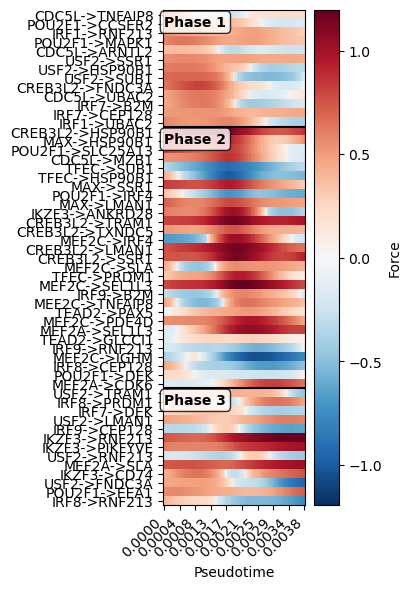

In [17]:
ordered_df, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_pb.force_curves,
    dtime=waves_pb.dtime,
    links=links,
    switch_pseudotimes=switch_pseudotimes,
)
plt.show()

## GC links

In [18]:
# TF forces over pseudotime (expression / regulation curves cached internally)
waves_gc = sd.TFForceWaves(
    dictys_dynamic_object,
    trajectory_range=(0, 3),
    num_points=100,
    dist=0.0005,
    sparsity=0.01,
)

In [19]:
# episodic links as (TF, target) tuples (already built in the cell above)
links = sorted(episodic_links_tuples)

# 1) compute & cache force curves for these links on the PB branch (0->2)
waves_gc.compute_forces(links)

time_0    time_1    time_2    time_3    time_4    time_5  \
TF   Target                                                                
IRF8 CCSER2   0.266333  0.267373  0.268485  0.269678  0.270959  0.272337   
     PDE4D   -0.136323 -0.136272 -0.136153 -0.135965 -0.135711 -0.135391   
     UBAC2    0.067418  0.070179  0.073376  0.076973  0.080936  0.085233   
     PRDM1    0.343693  0.344794  0.345784  0.346660  0.347415  0.348046   
     MAPK1    0.413959  0.416319  0.418498  0.420495  0.422311  0.423944   
...                ...       ...       ...       ...       ...       ...   
MAX  ARNTL2  -0.189737 -0.192210 -0.194722 -0.197279 -0.199891 -0.202568   
     ANKRD28 -0.102893 -0.107212 -0.111448 -0.115617 -0.119734 -0.123812   
     CD74    -0.210681 -0.212666 -0.214655 -0.216641 -0.218618 -0.220577   
     SLA     -0.070942 -0.077775 -0.084104 -0.090056 -0.095720 -0.101156   
     MZB1    -0.157528 -0.165197 -0.172323 -0.178977 -0.185213 -0.191077   

                time_6    time_7    time_8    time_9  ...   time_90   time_91  \
TF   Target                                           ...                       
IRF8 CCSER2   0.273819  0.275413  0.277128  0.278970  ... -0.218523 -0.218340   
     PDE4D   -0.135006 -0.134556 -0.134043 -0.133467  ... -0.223743 -0.224025   
     UBAC2    0.089838  0.094729  0.099891  0.105310  ... -0.095323 -0.099244   
     PRDM1    0.348543  0.348900  0.349106  0.349148  ... -0.098835 -0.095502   
     MAPK1    0.425393  0.426656  0.427730  0.428612  ...  0.161587  0.162402   
...                ...       ...       ...       ...  ...       ...       ...   
MAX  ARNTL2  -0.205320 -0.208158 -0.211096 -0.214145  ...  0.257441  0.257803   
     ANKRD28 -0.127865 -0.131903 -0.135938 -0.139980  ... -0.240856 -0.240358   
     CD74    -0.222513 -0.224416 -0.226280 -0.228094  ... -0.181174 -0.182919   
     SLA     -0.106414 -0.111529 -0.116532 -0.121448  ...  0.203798  0.204142   
     MZB1    -0.196605 -0.201828 -0.206774 -0.211467  ...  0.265095  0.265657   

               time_92   time_93   time_94   time_95   time_96   time_97  \
TF   Target                                                                
IRF8 CCSER2  -0.218173 -0.218024 -0.217893 -0.217779 -0.217683 -0.217605   
     PDE4D   -0.224281 -0.224513 -0.224721 -0.224908 -0.225073 -0.225219   
     UBAC2   -0.102826 -0.106116 -0.109154 -0.111970 -0.114590 -0.117035   
     PRDM1   -0.091846 -0.087825 -0.083380 -0.078432 -0.072861 -0.066482   
     MAPK1    0.163160  0.163863  0.164514  0.165115  0.165668  0.166174   
...                ...       ...       ...       ...       ...       ...   
MAX  ARNTL2   0.258147  0.258476  0.258791  0.259093  0.259383  0.259663   
     ANKRD28 -0.239852 -0.239339 -0.238822 -0.238303 -0.237781 -0.237259   
     CD74    -0.184678 -0.186448 -0.188226 -0.190011 -0.191798 -0.193588   
     SLA      0.204453  0.204730  0.204978  0.205198  0.205392  0.205562   
     MZB1     0.266194  0.266708  0.267199  0.267672  0.268126  0.268564   

               time_98   time_99  
TF   Target                       
IRF8 CCSER2  -0.217544 -0.217499  
     PDE4D   -0.225346 -0.225454  
     UBAC2   -0.119321 -0.121464  
     PRDM1   -0.058975 -0.049710  
     MAPK1    0.166636  0.167055  
...                ...       ...  
MAX  ARNTL2   0.259934  0.260197  
     ANKRD28 -0.236739 -0.236220  
     CD74    -0.195377 -0.197164  
     SLA      0.205708  0.205834  
     MZB1     0.268986  0.269395  

[434 rows x 100 columns]

In [20]:
# 2) GC phase boundaries = cell-state termination pseudotimes (2 phases)
sf = sd.StateFrequency(
    dictys_dynamic_object,
    cell_labels=config.CELL_LABELS,
    colors=colors_cell_count,
    trajectory_range=(0, 3),
)
switch_pseudotimes = [
    sf.termination_pseudotime(state, GC_post_bifurcation_window_indices)
    for state in ['ActB-3']
]

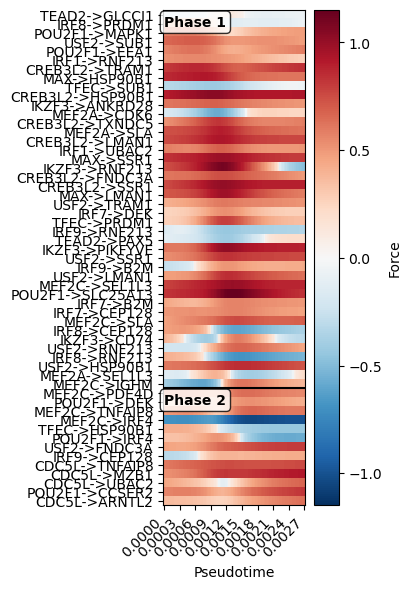

In [21]:
ordered_df, phases, fig = sd.plot_force_heatmap_by_phase(
    force_curves=waves_gc.force_curves,
    dtime=waves_gc.dtime,
    links=links,
    switch_pseudotimes=switch_pseudotimes,
)
plt.show()